In [1]:
# Training name
training_name = 'Transformer0e_3bit'

# Gaussian noise parameters
NOISE_MU = 0.0
NOISE_SIGMA = 0.0 # e-

# Precision of input data
N_BITS = 3

In [2]:
# IMPORTS ---------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import os
import random

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

from models import *
from plotting import *

2026-04-15 21:21:19.148536: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
fingerprints = ['8f9c3f63',
                '1aa2dd58',
                '92381e83',
                'a05f2088',
                '50c5ddee',
                '6cd90e9d',
                'e8872079',
                'f9fe08a4']

print("Fingerprints = ", fingerprints)


Fingerprints =  ['8f9c3f63', '1aa2dd58', '92381e83', 'a05f2088', '50c5ddee', '6cd90e9d', 'e8872079', 'f9fe08a4']


8f9c3f63 269 -22090.205078125
1aa2dd58 1 102835.7578125
92381e83 2695 -55098.62109375
a05f2088 3582 -55580.796875
50c5ddee 67 -24162.423828125
6cd90e9d 2078 -54473.75
e8872079 1530 -32457.08203125
History not available for model e8872079 at epoch 1530
f9fe08a4 1918 -54711.60546875


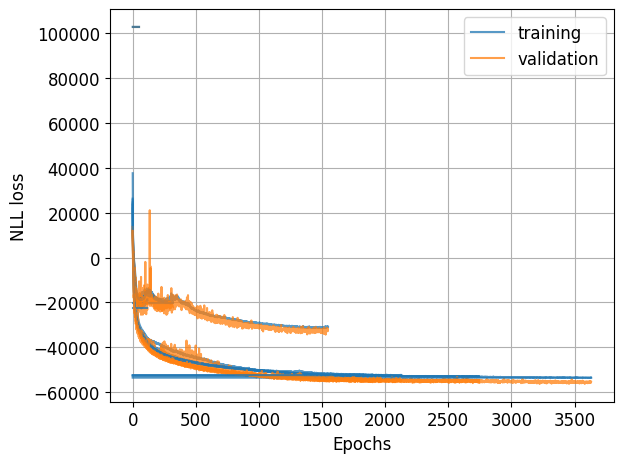

In [9]:
thresholds = {}
best_epoch = {}

for i in range(len(fingerprints)):

    try:
    
        base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
        if not os.path.exists(base_dir):
            print("Fingerprint " + fingerprints[i] + " not found")
            continue

        checkpoint_dir = base_dir + 'checkpoints/'
        checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
    
        checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
        best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]
        #os.system('cp '+best_checkpoint+' ' +base_dir)

        best_epoch[i] = int(best_checkpoint.split('weights.')[1].split('-t')[0])
            
        thr = pd.read_csv(base_dir+'soft_quantizer_state_log.csv',header=0,index_col=0,usecols=['epoch'] + ['threshold_'+str(i) for i in range(0,7)])
        thresholds[i] = thr

        training_cp_path = os.path.join(base_dir, 'training_log.csv')
        training_history = pd.read_csv(training_cp_path)

        print(fingerprints[i], best_epoch[i], training_history['val_loss'][best_epoch[i]])

        plt.plot(training_history['epoch'][:best_epoch[i]+50], training_history['loss'][:best_epoch[i]+50], linestyle='-', color=colors[0], alpha=0.75)
        plt.plot(training_history['epoch'][:best_epoch[i]+50], training_history['val_loss'][:best_epoch[i]+50], linestyle='-', color=colors[1], alpha=0.75)
        plt.plot(training_history['epoch'][:best_epoch[i]+50], (best_epoch[i]+50)*[training_history['loss'][best_epoch[i]]], linestyle='-', color=colors[0], alpha=0.75)


    except ValueError:
        print("History not available for model " + fingerprints[i] + " at epoch " + str(best_epoch[i]))
    
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

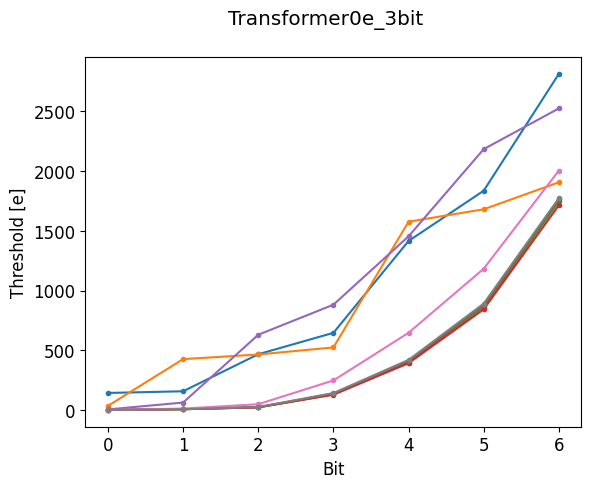

In [11]:
# OVERLAY THRESHOLDS OF ALL TRAININGS --------------------------------------

for i,df in thresholds.items():

    thr = np.array(df.iloc[best_epoch[i]].values)

    plt.plot(np.array(range(np.power(2,N_BITS)-1)), thr, linestyle='-',marker='.',label=str(i))
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

plt.suptitle(training_name);

(0.0, 4000.0)

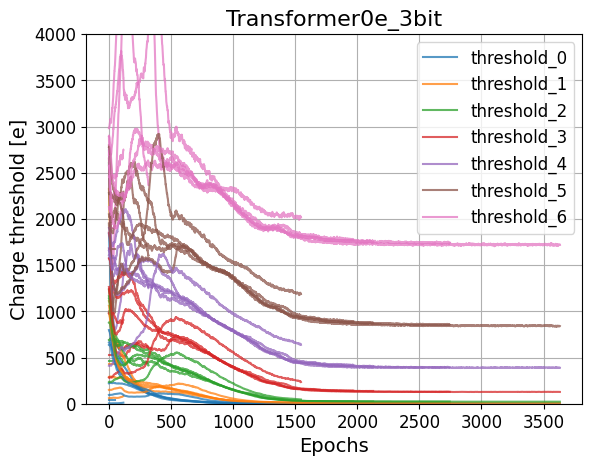

In [12]:
# THRESHOLD EVOLUTION --------------------------------------

plt.grid()

for i,df in thresholds.items():

    for j,c in enumerate(df.columns):
        epochs = df.index
        th_charge = df['threshold_'+str(j)]
        plt.plot(epochs[:best_epoch[i]+50], th_charge[:best_epoch[i]+50], linestyle='-', color=colors[j], alpha=0.75)


plt.legend([f'threshold_{i}' for i in range(7)],bbox_to_anchor=[1,1])
plt.xlabel('Epochs', fontsize =14)
plt.ylabel('Charge threshold [e]', fontsize = 14)
plt.title(training_name, fontsize = 16);

plt.ylim(0,4000)


In [ ]:
# AVERAGE THRESHOLDS --------------------------------------

th0 = [thresholds[i].iloc[best_epoch[i]][0] for i in range(len(best_epoch))]
th1 = [thresholds[i].iloc[best_epoch[i]][1] for i in range(len(best_epoch))]
th2 = [thresholds[i].iloc[best_epoch[i]][2] for i in range(len(best_epoch))]
th3 = [thresholds[i].iloc[best_epoch[i]][3] for i in range(len(best_epoch))]
th4 = [thresholds[i].iloc[best_epoch[i]][4] for i in range(len(best_epoch))]
th5 = [thresholds[i].iloc[best_epoch[i]][5] for i in range(len(best_epoch))]
th6 = [thresholds[i].iloc[best_epoch[i]][6] for i in range(len(best_epoch))]

th0_mean = np.mean(th0)
th0_sigma = np.std(th0)

th1_mean = np.mean(th1)
th1_sigma = np.std(th1)

th2_mean = np.mean(th2)
th2_sigma = np.std(th2)

th3_mean = np.mean(th3)
th3_sigma = np.std(th3)

th4_mean = np.mean(th4)
th4_sigma = np.std(th4)

th5_mean = np.mean(th5)
th5_sigma = np.std(th5)

th6_mean = np.mean(th6)
th6_sigma = np.std(th6)

plt.errorbar(x=np.array(range(np.power(2,N_BITS)-1)), y=[th0_mean,th1_mean,th2_mean,th3_mean,th4_mean,th5_mean,th6_mean], 
             yerr=[th0_sigma,th1_sigma,th2_sigma,th3_sigma,th4_sigma,th5_sigma,th6_sigma], 
             linestyle='-',marker='.',label=training_name)
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

height = 2000
delta = 150
plt.text(0,height - 0*delta,r"Th$_0=$"+str(int(th0_mean))+"$\pm$"+str(int(th0_sigma)))
plt.text(0,height - 1*delta,r"Th$_1=$"+str(int(th1_mean))+"$\pm$"+str(int(th1_sigma)))
plt.text(0,height - 2*delta,r"Th$_2=$"+str(int(th2_mean))+"$\pm$"+str(int(th2_sigma)))
plt.text(0,height - 3*delta,r"Th$_3=$"+str(int(th3_mean))+"$\pm$"+str(int(th3_sigma)))
plt.text(0,height - 4*delta,r"Th$_4=$"+str(int(th4_mean))+"$\pm$"+str(int(th4_sigma)))
plt.text(0,height - 5*delta,r"Th$_5=$"+str(int(th5_mean))+"$\pm$"+str(int(th5_sigma)))
plt.text(0,height - 6*delta,r"Th$_6=$"+str(int(th6_mean))+"$\pm$"+str(int(th6_sigma)))

data = np.array([[th0_mean,th0_sigma],
                 [th1_mean,th1_sigma],
                 [th2_mean,th2_sigma],
                 [th3_mean,th3_sigma],
                 [th4_mean,th4_sigma],
                 [th5_mean,th5_sigma],
                 [th6_mean,th6_sigma]])
df = pd.DataFrame(data,columns=['mean','sigma'])

df.to_parquet("avg_thr_"+training_name+".parquet")